In [60]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn import linear_model
from sklearn.metrics import r2_score

In [61]:
#using a dataset from seaborn
df_taxis = sns.load_dataset('taxis')
df_taxis.head(5)

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan


In [62]:
#data cleaning
df_taxis.isnull().sum()

pickup              0
dropoff             0
passengers          0
distance            0
fare                0
tip                 0
tolls               0
total               0
color               0
payment            44
pickup_zone        26
dropoff_zone       45
pickup_borough     26
dropoff_borough    45
dtype: int64

In [63]:
#dropping the null values
df_taxis.dropna(inplace=True)

In [64]:
df_taxis.columns

Index(['pickup', 'dropoff', 'passengers', 'distance', 'fare', 'tip', 'tolls',
       'total', 'color', 'payment', 'pickup_zone', 'dropoff_zone',
       'pickup_borough', 'dropoff_borough'],
      dtype='object')

- Determining approximately how much fare a driver gets based on passengers and distance travelled and duration

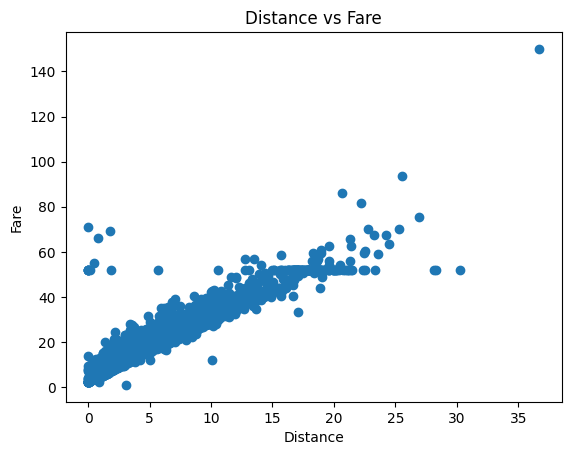

In [65]:
#exploring the relationship between distance and fare
import matplotlib.pyplot as plt

plt.scatter(df_taxis['distance'], df_taxis['fare'])
plt.xlabel("Distance")
plt.ylabel("Fare")
plt.title("Distance vs Fare")
plt.show()


In [66]:
df_taxis[['distance','passengers','fare']].corr()

,distance,passengers,fare
distance,1.000000,0.005481,0.947958
passengers,0.005481,1.000000,-0.000912
fare,0.947958,-0.000912,1.000000


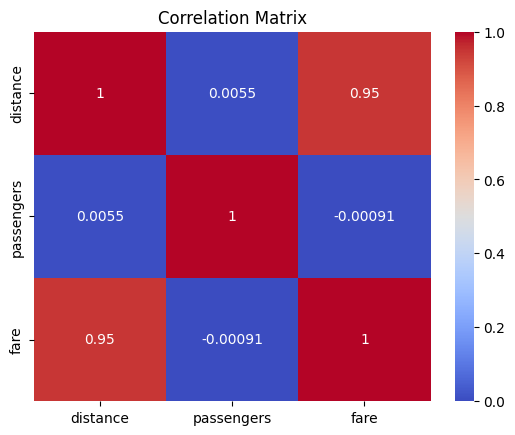

In [67]:
import seaborn as sns

sns.heatmap(df_taxis[['distance','passengers','fare']].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [68]:
from sklearn import linear_model
x = df_taxis[['distance','passengers']]
y = df_taxis['fare']

In [69]:
regr = linear_model.LinearRegression()
regr.fit(x,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [70]:
#Evaluating the model using train/test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=0)
regr.fit(X_train,y_train)

y_pred = regr.predict(X_test)
print(r2_score(y_test,y_pred))

0.8881790656989103


- The R2_score is close to one meaning the model can predict predict upto 88% of the fares drivers get

In [73]:
print(regr.coef_)

[ 2.7252099  -0.04648646]


In [75]:
#making a predition using my model
distance = 5.0
passengers = 2
prediction = regr.predict([[distance,passengers]])
print(f"Predicted fare: ${prediction[0]:.2f}")

Predicted fare: $18.29


c:\Users\sanke\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


- For a 5km trip with 2 passengers the model predicts a fare of $18.29- this aligns with the fare structure down below

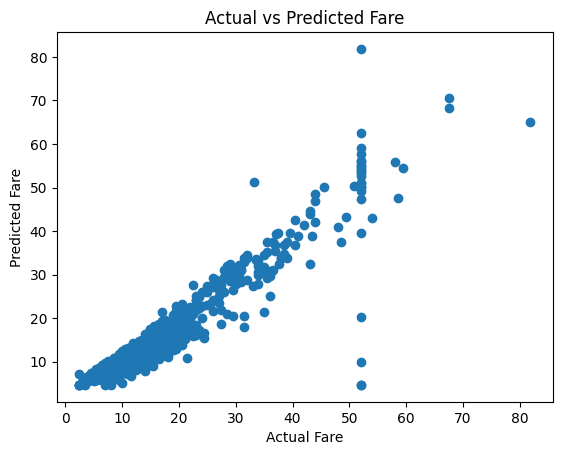

In [76]:
#comparing actual vs predicted values
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Fare")
plt.ylabel("Predicted Fare")
plt.title("Actual vs Predicted Fare")
plt.show()